In [2]:
import pandas as pd
from matplotlib.pyplot import *
from scipy import stats

In [ ]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
#COLORS_COND = {NARROW:'C0', WIDE:'C1'}
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [4]:
summary = pd.read_csv('stan/outputs/summaries/results_20250804142343.csv', index_col=0)
summary

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-27492.900000,1.445580,64.076200,-27598.500000,-27492.700000,-27387.400000,1964.75,2.74674,1.005410
z_m_0_15[1],0.114643,0.000610,0.022097,0.078647,0.114326,0.150892,1313.64,1.83648,1.006480
z_m_0_15[2],0.099765,0.000491,0.021970,0.063631,0.099903,0.135862,2005.60,2.80384,1.002830
z_m_0_15[3],0.116497,0.000451,0.022825,0.077950,0.116756,0.153092,2565.87,3.58710,1.004710
z_m_0_15[4],0.101402,0.000490,0.022985,0.063149,0.101322,0.139929,2202.59,3.07923,1.003830
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.511716,0.001204,0.155589,0.254324,0.512230,0.766236,16711.80,23.36320,0.999623
delta_avg_log_var_s_1322[36],0.623126,0.001238,0.153333,0.369549,0.623440,0.874242,15338.40,21.44320,1.000040
delta_avg_log_var_s_1322[37],0.728464,0.001248,0.157262,0.470623,0.728124,0.988688,15884.40,22.20650,0.999400
delta_avg_log_var_s_1322[38],0.489369,0.001246,0.158180,0.232830,0.489670,0.753400,16118.80,22.53420,0.999705


In [5]:
zs = []
for x in summary.index:
    ys = x.split('[')
    if len(ys) == 1:
        zs.append(ys[0])
    else:
        ts = ys[1].split(',')
        if len(ts) == 1:
            zs.append(ys[0] + '[i]')
        else:
            zs.append(ys[0] + '[i,j]')
zs = set(zs)
zs

{'avg_inv_sigma_0_15',
 'avg_inv_sigma_0_30',
 'avg_inv_sigma_0_30_narrowrange',
 'avg_inv_sigma_s_15[i]',
 'avg_inv_sigma_s_15_1124[i]',
 'avg_inv_sigma_s_15_1223[i]',
 'avg_inv_sigma_s_15_1322[i]',
 'avg_inv_sigma_s_30[i]',
 'avg_inv_sigma_s_30_1124[i]',
 'avg_inv_sigma_s_30_1223[i]',
 'avg_inv_sigma_s_30_1322[i]',
 'avg_inv_sigma_s_30_narrowrange[i]',
 'avg_log_var_0_15',
 'avg_log_var_0_30',
 'avg_log_var_0_30_narrowrange',
 'avg_log_var_s_15[i]',
 'avg_log_var_s_15_1124[i]',
 'avg_log_var_s_15_1223[i]',
 'avg_log_var_s_15_1322[i]',
 'avg_log_var_s_30[i]',
 'avg_log_var_s_30_1124[i]',
 'avg_log_var_s_30_1223[i]',
 'avg_log_var_s_30_1322[i]',
 'avg_log_var_s_30_narrowrange[i]',
 'avg_sigma_0_15',
 'avg_sigma_0_30',
 'avg_sigma_0_30_narrowrange',
 'avg_sigma_s_15[i]',
 'avg_sigma_s_15_1124[i]',
 'avg_sigma_s_15_1223[i]',
 'avg_sigma_s_15_1322[i]',
 'avg_sigma_s_30[i]',
 'avg_sigma_s_30_1124[i]',
 'avg_sigma_s_30_1223[i]',
 'avg_sigma_s_30_1322[i]',
 'avg_sigma_s_30_narrowrange[i]',
 

In [6]:
summary.loc[['sqrt_mse_15[10]', 'log_var_0_15[1]', 'sigma_0_15[10]', 'var_0_15[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
sqrt_mse_15[10],2.07283,0.001320,0.105101,1.905550,2.069430,2.248910,6342.03,8.86621,1.000240
log_var_0_15[1],0.66160,0.001353,0.100909,0.499379,0.661318,0.827435,5564.94,7.77983,1.000760
sigma_0_15[10],2.05778,0.001285,0.103721,1.893590,2.055770,2.232320,6519.83,9.11477,0.999947
var_0_15[10],4.24521,0.005315,0.429109,3.585690,4.226200,4.983270,6517.71,9.11181,0.999983


In [7]:
summary.loc[['tau', 'nu']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,1.30431,0.00069,0.03710,1.24279,1.30456,1.36542,2902.74944,4.05806,1.00254
nu,0.22875,0.00014,0.00867,0.21442,0.22873,0.24308,3864.39474,5.40245,1.00163


In [8]:
( summary.R_hat > 1.01 ).mean()

0.0

In [9]:
summary[summary.R_hat>1.01]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat


In [10]:
summary.loc[[f'sigma_0_15[{i}]' for i in range(1,17)] ] #
#summary.loc[['sigma_0_15', 'sigma_0_30'] ] #

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
sigma_0_15[1],1.39386,0.000944,0.070443,1.28363,1.39188,1.51243,5572.61,7.79055,1.000730
sigma_0_15[2],1.69764,0.001101,0.084799,1.56221,1.69488,1.84245,5928.89,8.28864,1.001530
sigma_0_15[3],2.02295,0.001230,0.098673,1.86424,2.02028,2.19255,6439.10,9.00190,1.000060
sigma_0_15[4],1.93214,0.001192,0.093809,1.78331,1.92930,2.09137,6196.86,8.66326,1.000150
sigma_0_15[5],1.95892,0.001312,0.097488,1.80318,1.95509,2.12323,5518.27,7.71458,1.001520
sigma_0_15[6],2.08522,0.001235,0.099059,1.92596,2.08253,2.25317,6430.98,8.99055,1.000110
sigma_0_15[7],2.04452,0.001203,0.097166,1.89020,2.04214,2.20784,6525.90,9.12325,1.000610
sigma_0_15[8],2.00769,0.001233,0.097375,1.85269,2.00443,2.17201,6236.77,8.71905,1.000190
sigma_0_15[9],2.03758,0.001283,0.100821,1.87657,2.03669,2.20571,6171.64,8.62799,0.999811
sigma_0_15[10],2.05778,0.001285,0.103721,1.89359,2.05577,2.23232,6519.83,9.11477,0.999947


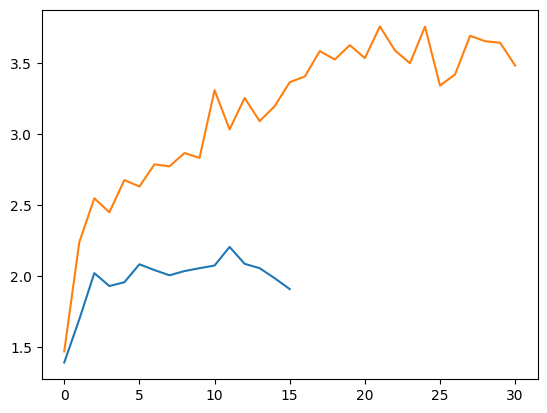

In [11]:
plot( summary.loc[[f'sigma_0_15[{i}]' for i in range(1,16+1)] ].Mean.values )
plot( summary.loc[[f'sigma_0_30[{i}]' for i in range(1,31+1)] ].Mean.values )

In [12]:
summary.loc[[f'sigma_s_15[{sid},{i}]' for i in range(1,17) for sid in range(1,40)] ]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
"sigma_s_15[1,1]",2.06543,0.002039,0.246991,1.697130,2.04564,2.50044,14668.8,20.5071,0.999380
"sigma_s_15[2,1]",2.39773,0.002285,0.304233,1.950460,2.37026,2.93868,17729.1,24.7854,0.999739
"sigma_s_15[3,1]",1.84222,0.002004,0.257361,1.463710,1.81577,2.30214,16490.2,23.0534,0.999305
"sigma_s_15[4,1]",2.59819,0.002771,0.339851,2.098030,2.57136,3.21280,15046.3,21.0348,0.999400
"sigma_s_15[5,1]",1.12663,0.001195,0.146954,0.910458,1.11149,1.39229,15133.0,21.1561,0.999335
...,...,...,...,...,...,...,...,...,...
"sigma_s_15[35,16]",1.85579,0.002181,0.266240,1.466850,1.83114,2.33191,14899.8,20.8300,0.999558
"sigma_s_15[36,16]",1.62703,0.002210,0.272753,1.238440,1.60059,2.11366,15232.7,21.2954,0.999623
"sigma_s_15[37,16]",1.73853,0.002330,0.271496,1.345650,1.71347,2.22492,13581.6,18.9872,0.999628
"sigma_s_15[38,16]",1.85108,0.002422,0.299763,1.417590,1.82088,2.38113,15321.3,21.4193,0.999754


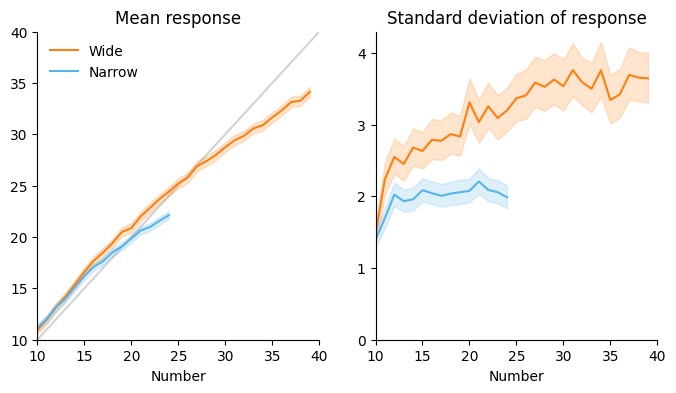

In [13]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_subjects_stan(ax_m, ax_sigma):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = {'m_0': ax_m, 'sigma_0': ax_sigma}[qty]
        if ax is None:
            continue
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+1):
                r = summary.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize())
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    if False:
        ### TESTS ###
            print('mean', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_m_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = summary.loc[f'bin_avg_m_0[2,{i+1}]']['Mean']+1  #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,0].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nvariance', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_sigma_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = max(summary.loc[f'bin_avg_sigma_0[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sigma_0[1,{i+1}]']['Mean']) + [.5,.3][ie]
                #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,1].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nmse', end=' ')
            # computed on server
            p_pos_priors = np.array([0.4113, 1.    , 1.    , 0.1961, 0.    , 0.    ])
            p_pos_stakes = np.array([1.    , 1.    , 1.    , 0.9938, 0.    , 0.    ])
            for i in range(nb_bins):
                # p_pos = summary.loc[f'bin_avg_sqrt_mse_diff_pos[{i+1}]']['Mean'].squeeze()
                p_pos = (p_pos_priors if experiment==PRIORS else p_pos_stakes)[i]
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = min(summary.loc[f'bin_avg_sqrt_mse[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sqrt_mse[1,{i+1}]']['Mean']) - .5
                if pv<.001:
                    axs[ie,2].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print()

plot_subjects_stan(axs[0], axs[1])
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)

In [14]:
np.arange(10, 10+W_NARROW+1)

array([10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22.,
       23., 24., 25.])

In [15]:
def norm(x, mu, w):
    return np.exp(-.5*((x-mu)/w)**2)

def prf(x, mu, w):
    return norm( np.log(x), np.log(mu), w )


In [16]:
def plot_prior(ax, x0, x1, v, c, zorder=None, ylabel='Probability'):
    ax.plot([x0,x1], [v, v], c=c, zorder=zorder)
    ax.plot([x0,x0], [0, v], c=c, ls=':', zorder=zorder)
    ax.plot([x1,x1], [0, v], c=c, ls=':', zorder=zorder)
    if ylabel:
        ax.set_ylabel(ylabel)

In [17]:
from matplotlib.patches import ConnectionPatch

7 10 13 16 19 22 25 

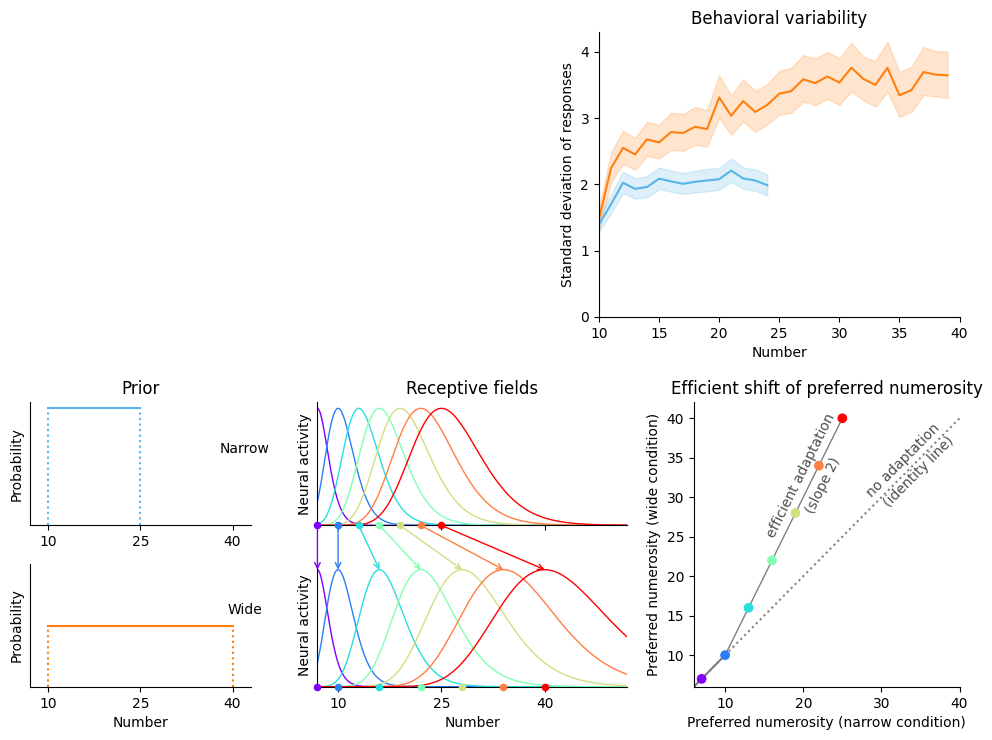

In [18]:
fig, axs = subplots(nrows=3, ncols=3, figsize=(12,8.5), width_ratios=[10,14,12], height_ratios=[2.7,1,1])

gs = axs[0, 0].get_gridspec()
for ax in axs[1:, 2]:
    ax.remove()
axbig = fig.add_subplot(gs[1:, 2])
axs[0,0].remove()
axs[0,1].remove()

axPriorN = axs[1,0]
axPriorW = axs[2,0]
axRF_N = axs[1,1]
axRF_W = axs[2,1]

#axStdDev = axs[0,2]
axs[0,2].remove()
gs_top = GridSpec(nrows=2, ncols=10, hspace=.3)
axStdDev = fig.add_subplot(gs_top[0, 6:])
#axStdDev = fig.add_subplot( 2, 2, 2 )

#### Std Dev subjects
plot_subjects_stan(ax_m=None, ax_sigma=axStdDev)
#axs[0].legend(loc='upper left')
#axs[0].set_title('Mean response')
axStdDev.set_title('Behavioral variability')
axStdDev.set_xlim(10,40)
axStdDev.spines['top'].set_visible(False)
axStdDev.spines['right'].set_visible(False)
axStdDev.set_ylim(0,None)
axStdDev.set_yticks([0,1,2,3,4])
axStdDev.set_xlabel('Number') # $x$
axStdDev.set_ylabel('Standard deviation of responses') # $\hat x$
#####

sigma = .2
xx = np.linspace(5, 56, 500)
no_change = False
pref_nums = np.arange(7, 26, 3)
num_tcs = len(pref_nums)
cmap = cm.rainbow

### priors
plot_prior(axPriorN, 10, 25, 1./16, c=COLORS_COND[NARROW])
plot_prior(axPriorW, 10, 40, 1./31, c=COLORS_COND[WIDE])
axPriorW.set_ylim( *axPriorN.get_ylim() )
axPriorW.set_xlabel('Number')
axPriorN.set_title('Prior')
axPriorN.text(42,1.2/31,'Narrow', ma='center', ha='center')
axPriorW.text(42,1.2/31,'Wide', ma='center', ha='center')
for ax in axs[1:,0]: ax.set_xlim(7,43)

### receptive fields
pref_nums_w = []
for ii,mode in enumerate( pref_nums ):
    #print(mode)
    c = cmap( (mode-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ) #cmap(ii/num_tcs)
    axRF_N.plot(xx, prf(xx, mode, sigma), lw=1, c=c)
    axRF_N.scatter(x=mode, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[0,1], 10, 25, .5, c=COLORS_COND[NARROW], ylabel=None, zorder=-1000)
    mode_w = mode if no_change or mode <= 10 else ( 10 + 2*(mode-10) )
    pref_nums_w.append(mode_w)
    sigma_w = sigma #if no_change else np.sqrt(2)*sigma
    axRF_W.plot(xx, prf(xx, mode_w, sigma_w), lw=1, c=c)
    axRF_W.scatter(x=mode_w, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[1,1], 10, 40, .25, c=COLORS_COND[WIDE], ylabel=None, zorder=-1000)
for ax in axs[1:,:2].flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylim(0,None); #ax.set_xlim(10,40)
    #ax.set_xticks([10,15,20,25,30,35,40])
    ax.set_xticks([10,25,40])
axRF_N.set_xticklabels([])
axRF_N.set_title('Receptive fields') #('Tuning curves')
axRF_N.set_ylabel('Neural activity')
axRF_W.set_ylabel('Neural activity')
axRF_W.set_xlabel('Number')
for ax in axs[1:,1]: ax.set_xlim(7,52)

#for pref_n in [10, 15, 20, 25]:
#for pref_n in pref_nums[1:]:
for pref_n in pref_nums[:]:
    print(pref_n, end=' ')
    pref_w = pref_n if no_change or pref_n <= 10 else ( 10 + 2*(pref_n-10) )
    c = cmap( (pref_n-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) )
    con = ConnectionPatch(xyA=(pref_n, 0), xyB=(pref_w, prf(pref_w,pref_w,sigma)), coordsA='data', coordsB='data',
            axesA=axRF_N, axesB=axRF_W, color=c, arrowstyle='->', linewidth=1, zorder=100)
    axRF_W.add_artist(con)

axbig.scatter(pref_nums, pref_nums_w, c=cmap( (pref_nums-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ), zorder=1000, clip_on=False)
axbig.plot([5,10], [5,10], c='grey')
axbig.axline([10,10], slope=1, ls=':', c='grey')
axbig.set_xlim(6, 40) # 28)
axbig.plot([10,25],[10,40], c='grey', lw=1)
axbig.spines['top'].set_visible(False)
axbig.spines['right'].set_visible(False)
#axbig.text(29.25, 29.8, 'no adaptation\n(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(27.75, 30, 'no adaptation', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(30, 28.8, '(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
# axbig.annotate('efficient adaptation\n(slope = 2)', xy=(20,30), xytext=(15, 35), c=(.2,)*3, ma='center', ha='center',
#                arrowprops=dict(arrowstyle="->", connectionstyle="arc", color='grey'), ) # rotation=0, 
axbig.text(15, 25, 'efficient adaptation', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.text(20, 28, '(slope 2)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.set_ylim(6, 42)
axbig.set_xlabel('Preferred numerosity (narrow condition)')
axbig.set_ylabel('Preferred numerosity (wide condition)')
axbig.set_title('Efficient shift of preferred numerosity')
fig.subplots_adjust(wspace=.25)

#fig.savefig('figures/subjs_stddev_priors_effcod.pdf', bbox_inches='tight')